In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

## Discrete fourier transform grid

Let's play around with this for a while

In [30]:
import os
import torch
from script.analysis.analysis_dft import Analysis
from script.model_dim_4_layer_3 import MinimalTransformer, vocab_size, test_loader


checkpoint_dir = '../checkpoints'
full_path = os.path.join(checkpoint_dir, 'dim_4_layer_3.pth')

checkpoint = torch.load(full_path)
checkpoint = checkpoint['model_state_dict']


model = MinimalTransformer(vocab_size=vocab_size)
analysis = Analysis(model=model, skeleton=checkpoint, vocab_size=vocab_size, data=test_loader) 


analysis.diagonal_sperectal_mass()
"Checked"



correct: 5000/5000 = 100.0%
unique (a,b) pairs seen: 60
Diagonal mass 0.38722068071365356


'Checked'

Let's try to visuzlize that heatmap in `nxn` lattice

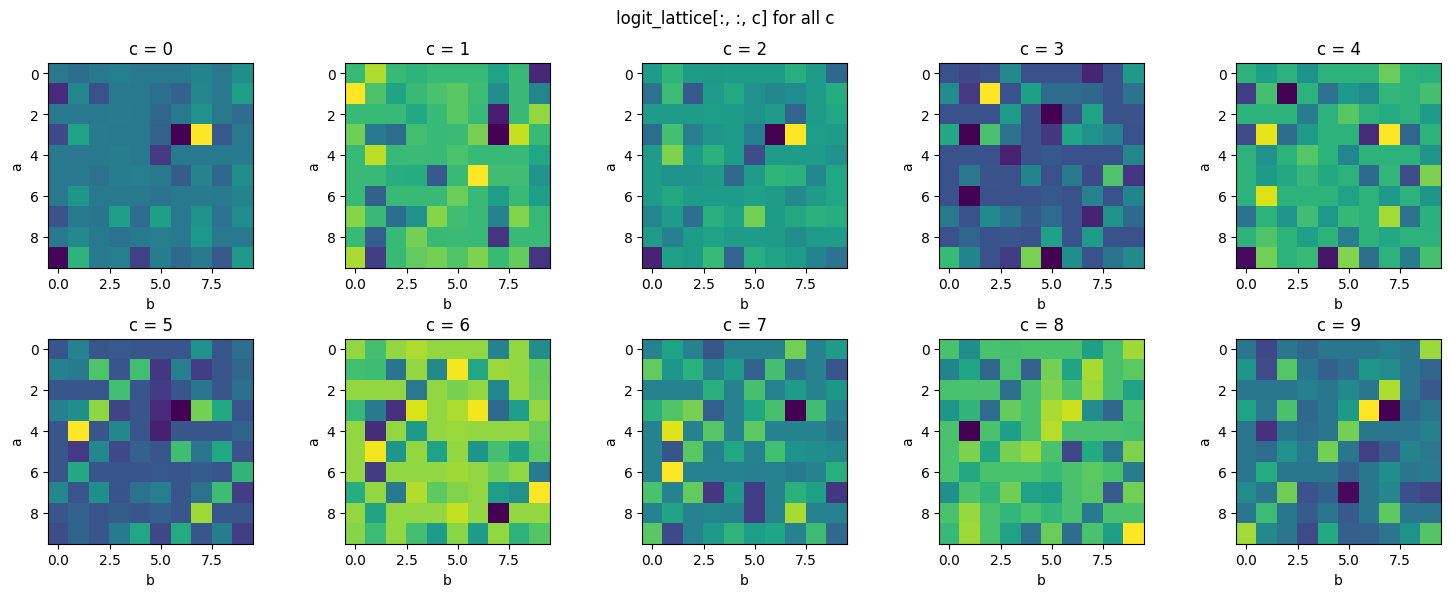

In [31]:
analysis.heat_map()

### Different approach of generating data

In [32]:
from torch.utils.data import random_split
from script.model_dim_4_layer_3 import FibonacciModDatasetSmallShample

generated_ds = FibonacciModDatasetSmallShample(num_samples=25000, mod=vocab_size, seq_len=20)

train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size])
print(test_ds[0])

(tensor([2, 0, 2, 2, 4, 6, 0, 6, 6, 2, 8, 0, 8, 8, 6, 4, 0, 4, 4, 8]), tensor([0, 2, 2, 4, 6, 0, 6, 6, 2, 8, 0, 8, 8, 6, 4, 0, 4, 4, 8, 2]))


### Let's see the same analysis in the model trained with `Alternate dataset`

In [33]:
import os
import torch
from script.analysis.analysis_dft import Analysis
from script.model_dim_4_layer_3 import MinimalTransformer, vocab_size, test_loader


checkpoint_dir = '../checkpoints'
full_path = os.path.join(checkpoint_dir, 'dim_4_layer_3_alterset.pth')

checkpoint = torch.load(full_path)
checkpoint = checkpoint['model_state_dict']


model = MinimalTransformer(vocab_size=vocab_size)
analysis = Analysis(model=model, skeleton=checkpoint, vocab_size=vocab_size, data=test_loader) 


analysis.diagonal_sperectal_mass()
"Checked"

correct: 5000/5000 = 100.0%
unique (a,b) pairs seen: 60
Diagonal mass 0.6127839088439941


'Checked'

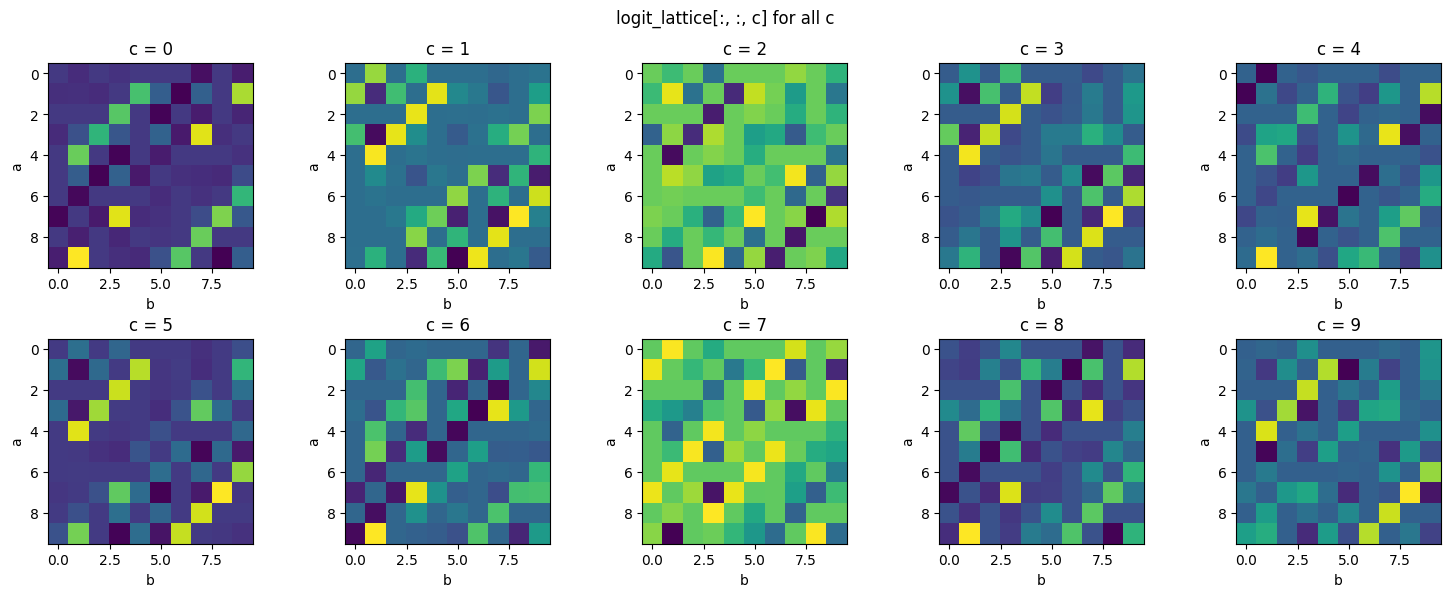

In [34]:
analysis.heat_map()